<a href="https://colab.research.google.com/github/VenkatNarayananManjunath/AI-Experiments/blob/main/PyGADoptimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 3.8 MB/s eta 0:00:00
Normal Accuracy = 0.956140350877193


/usr/local/lib/python3.12/dist-packages/pygad/pygad.py:753: UserWarning: The percentage of genes to mutate (mutation_percent_genes=20) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


Best K = 12
Best Accuracy = 0.9824561403508771


/usr/local/lib/python3.12/dist-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


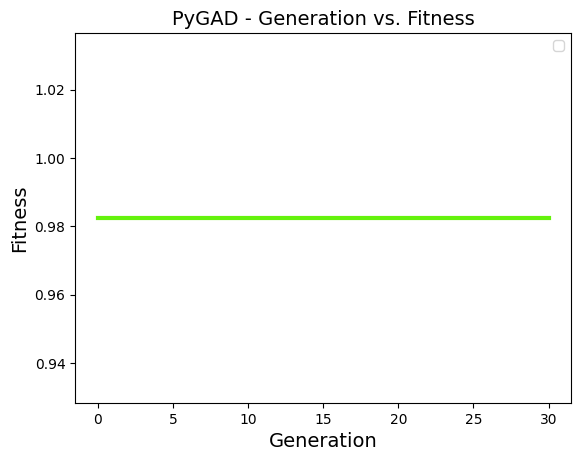

In [2]:
!pip install pygad
import numpy as np
import pygad
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load and prepare data
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Baseline model
normal_model = KNeighborsClassifier(n_neighbors=5)
normal_model.fit(X_train, y_train)
normal_pred = normal_model.predict(X_test)
normal_accuracy = accuracy_score(y_test, normal_pred)
print("Normal Accuracy =", normal_accuracy)

# GA Fitness function
def fitness_func(ga_instance, solution, solution_idx):
    k = int(solution[0])
    if k < 1:
        k = 1
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return accuracy_score(y_test, pred)

# GA Configuration
gene_space = [{'low': 1, 'high': 20}]
ga_instance = pygad.GA(
    num_generations=30,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=12,
    num_genes=1,
    gene_space=gene_space,
    mutation_percent_genes=20
)

ga_instance.run()
solution, solution_fitness, _ = ga_instance.best_solution()
print("Best K =", int(solution[0]))
print("Best Accuracy =", solution_fitness)
ga_instance.plot_fitness()
plt.show()